In [328]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv

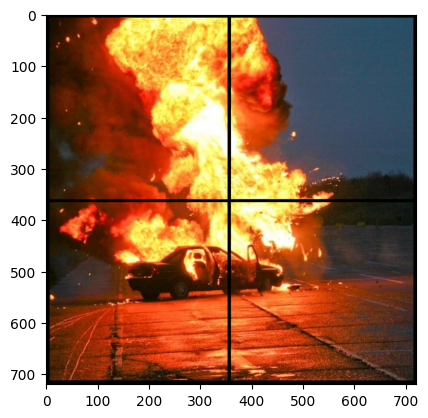

In [329]:
Meledak = plt.imread('Assets/Meledak.png')

plt.imshow(Meledak, cmap="gray")

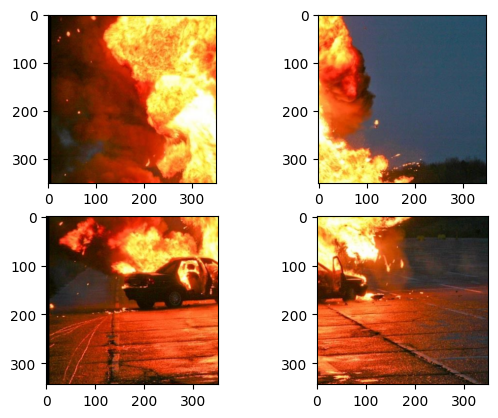

In [330]:
potong1 = Meledak[10:360,0:350]
potong2 = Meledak[10:360,360:710]

potong3 = Meledak[367:710,0:350]
potong4 = Meledak[367:710,360:710]

plt.subplot(2, 2, 1)
plt.imshow(potong1, cmap = "gray")

plt.subplot(2, 2, 2)
plt.imshow(potong2, cmap = "gray")

plt.subplot(2, 2, 3)
plt.imshow(potong3, cmap = "gray")

plt.subplot(2, 2, 4)
plt.imshow(potong4, cmap = "gray")

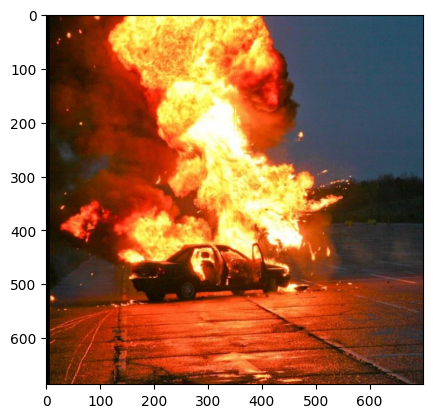

In [331]:
def ukuran_min(gambar):
    baris_min = min(len(citra) for citra in gambar)
    kolom_min = min(len(citra[0]) for citra in gambar)
    return baris_min, kolom_min

def potong(citra, tinggi, lebar):
    return [row[:lebar] for row in citra[:tinggi]]

def resize_semua(gambar):
    tinggi_min, lebar_min = ukuran_min(gambar)
    return [potong(citra, tinggi_min, lebar_min) for citra in gambar]

def ukuran_max(gambar):
    baris_max = max(len(citra) for citra in gambar)
    kolom_max = max(len(row) for citra in gambar for row in citra)
    return baris_max, kolom_max

def normalisasi(citra, baris_tujuan, kolom_tujuan):
    hasil = []
    for i in range(baris_tujuan):
        baris = []
        for j in range(kolom_tujuan):
            if i < len(citra) and j < len(citra[i]):
                baris.append(citra[i][j])
            else:
                baris.append(0)
        hasil.append(baris)
    return hasil

def gabung_2x2(citra1, citra2, citra3, citra4):
    citra1, citra2, citra3, citra4 = resize_semua([citra1, citra2, citra3, citra4])

    b, k = ukuran_max([citra1, citra2, citra3, citra4])
    i1 = normalisasi(citra1, b, k)
    i2 = normalisasi(citra2, b, k)
    i3 = normalisasi(citra3, b, k)
    i4 = normalisasi(citra4, b, k)

    gabung = []
    for i in range(b * 2):
        baris = []
        for j in range(k * 2):
            if i < b and j < k:
                baris.append(i1[i][j]) 
            elif i < b and j >= k:
                baris.append(i2[i][j - k]) 
            elif i >= b and j < k:
                baris.append(i3[i - b][j])
            else:
                baris.append(i4[i - b][j - k]) 
        gabung.append(baris)

    return gabung

gabung = gabung_2x2(potong1, potong2, potong3, potong4)

plt.imshow(gabung, cmap="gray")


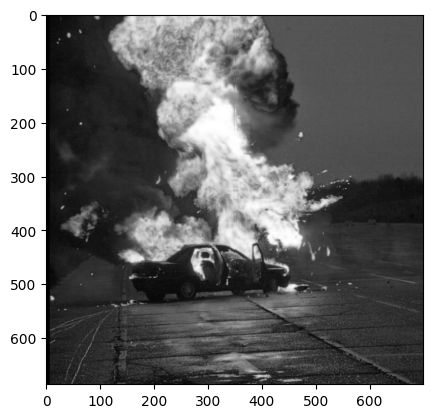

In [332]:
gabung = np.array(gabung, dtype=np.float32)  # ← tambahkan ini

gabung = cv.cvtColor(gabung, cv.COLOR_BGR2GRAY)
plt.imshow(gabung, cmap='gray')
plt.show()

In [333]:
# Fungsi untuk ekualisasi histogram
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    # Hitung histogram
    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    # Hitung CDF
    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    # Normalisasi CDF
    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    # Petakan nilai baru
    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

In [334]:
def hitung_histogram(gambar):
    img_arr = np.array(gambar)
    
    if len(img_arr.shape) == 3:
        img_arr = np.mean(img_arr, axis=2)
        
    if img_arr.max() <= 1.1:
        img_arr = img_arr * 255
        
    piksel_flat = img_arr.flatten().astype(int)
    
    histogram = [0] * 256
    for p in piksel_flat:
        if 0 <= p <= 255:
            histogram[p] += 1
    return histogram


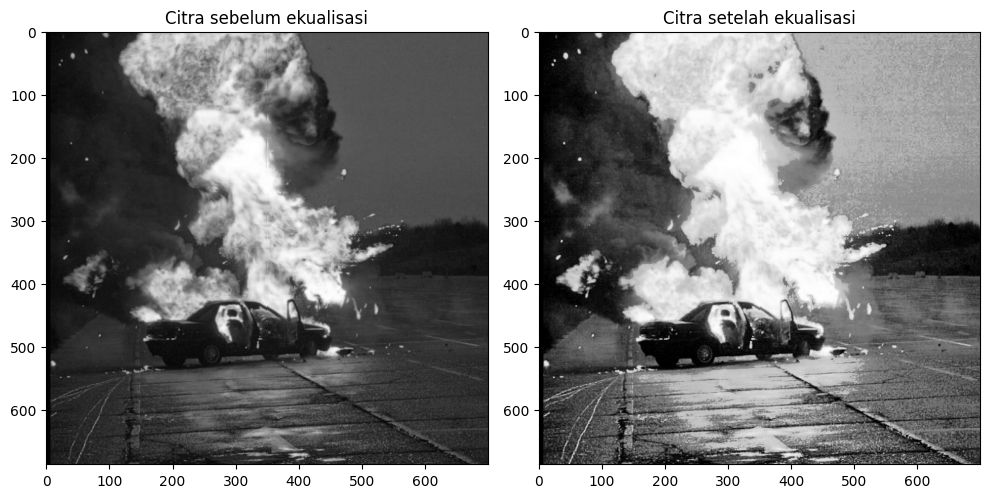

In [335]:
gabung = (gabung * 255).astype(np.uint8)

panjang, lebar = gabung.shape
hasil = ekualisasi_histogram(gabung)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gabung, cmap='gray')
plt.title("Citra sebelum ekualisasi")
plt.subplot(1, 2, 2)
plt.imshow(hasil, cmap='gray')
plt.title("Citra setelah ekualisasi")
plt.tight_layout()
plt.show()

Text(0, 0.5, 'Jumlah Pixel')

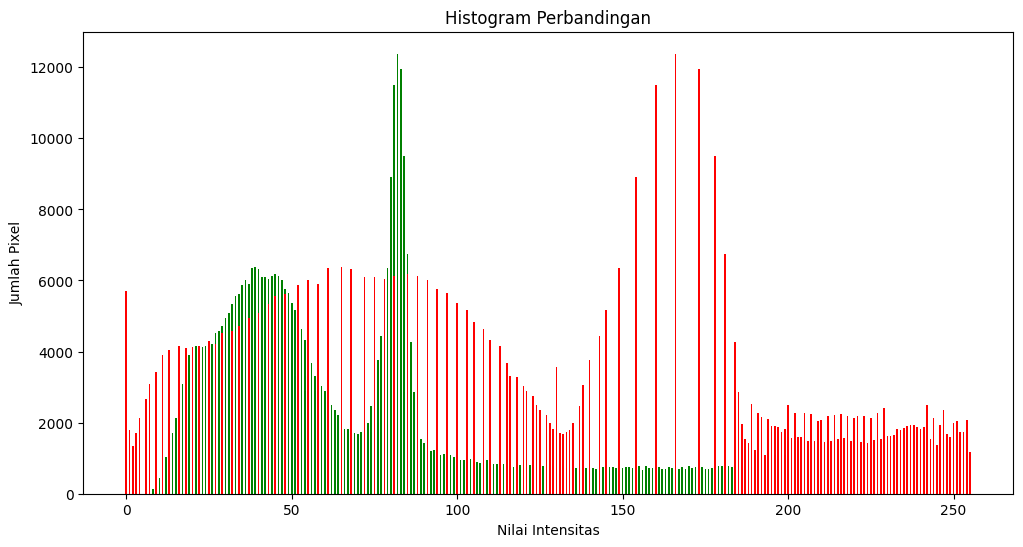

In [ ]:
sebelum = hitung_histogram(gabung)
sesudah = hitung_histogram(hasil)

plt.figure(figsize=(12, 6))

plt.bar(range(256), sebelum, width=0.5, color='green') # sebelum di tambahkan atribut

plt.bar(range(256), sesudah, width=0.5, color='red') # setelah di tambahkan atribut

plt.title('Gambar Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Intensitas Pixel')
plt.ylabel('Jumlah Pixel')

Text(0.5, 1.0, 'Citra Bunga Ireng')

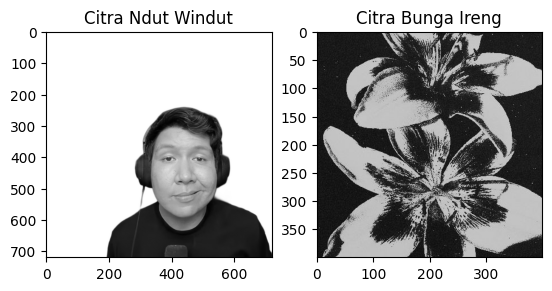

In [337]:
Windut = plt.imread('Assets/Windut.png')
Windut = cv.cvtColor(Windut,cv.COLOR_RGB2GRAY)
Bunga = plt.imread('Assets/Bunga.png')

plt.subplot(1, 2, 1)
plt.imshow(Windut, cmap='gray')
plt.title("Citra Ndut Windut")
plt.subplot(1, 2, 2)
plt.imshow(Bunga, cmap='gray')
plt.title("Citra Bunga Ireng")



In [ ]:
def spesifikasi_histogram(citra_sumber, citra_target):

    panjang_sumber, lebar_sumber = citra_sumber.shape
    panjang_target, lebar_target = citra_target.shape

    # Hitung histogram citra sumber & target
    histogram_sumber = np.zeros(256, dtype=int)
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            nilai = citra_sumber[i, j]
            histogram_sumber[nilai] += 1

    histogram_target = np.zeros(256, dtype=int)
    for i in range(panjang_target):
        for j in range(lebar_target):
            nilai = citra_target[i, j]
            histogram_target[nilai] += 1

    # Hitung CDF citra sumber & target
    cdf_sumber = np.zeros(256, dtype=int)
    for i in range(256):
        cdf_sumber[i] = np.sum(histogram_sumber[:i+1])

    cdf_sumber_min = cdf_sumber[cdf_sumber > 0].min() if np.any(cdf_sumber > 0) else 0
    cdf_sumber_norm = (cdf_sumber - cdf_sumber_min) / (panjang_sumber * lebar_sumber - cdf_sumber_min)

    cdf_target = np.zeros(256, dtype=int)
    for i in range(256):
        cdf_target[i] = np.sum(histogram_target[:i+1])

    cdf_target_min = cdf_target[cdf_target > 0].min() if np.any(cdf_target > 0) else 0
    cdf_target_norm = (cdf_target - cdf_target_min) / (panjang_target * lebar_target - cdf_target_min)

    # Mencari nilai terdekat
    pemetaan = np.zeros(256, dtype=int)
    for i in range(256):
        idx = np.argmin(np.abs(cdf_target_norm - cdf_sumber_norm[i]))
        pemetaan[i] = idx

    # Terapkan pemetaan ke citra sumber
    hasil = np.zeros_like(citra_sumber)
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            nilai = citra_sumber[i, j]
            hasil[i, j] = pemetaan[nilai]

    return hasil



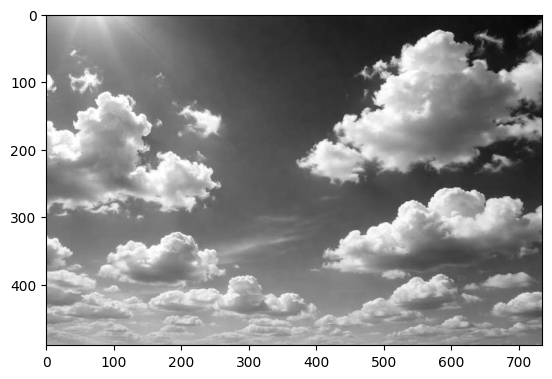

In [339]:
langitku = plt.imread('Assets/Langit.png')
langitku = cv.cvtColor(langitku,cv.COLOR_RGB2GRAY)

plt.imshow(langitku,cmap="gray")